## 1. What this notebook computes

The pairing theorems of this chapter say what happens to the Lagrangian, the field
equations, the energy-momentum tensor and the current of the fields dirac16complex
and dirac16complex00 when the field $\Psi$ is replaced by $M\Psi$ for a fixed
$16 \times 16$ matrix $M$. Every step of their proofs is a statement about such
matrices. This notebook first shows that the matrices used are exactly the
author's: it rebuilds the eight real $16 \times 16$ gamma matrices from the
author's own formulas and compares them entry by entry with the Revision record.
Then it proves all the matrix statements of the theorems exactly, with
whole-number arithmetic (no rounding anywhere):

- **Lemma 1 (the chirality).** $\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\cdots
  \gamma^{(x_7)} = \mathrm{diag}(-I_8, I_8)$ is real and symmetric, $\Gamma^2 = 1$,
  $\Gamma$ anticommutes with each of the eight gammas and commutes with $C$ and with
  every generator $S^{ab}$; hence it commutes with every spin connection.
- **Lemma 2 (bilinears).** Under $\Psi \to \Gamma\Psi$ a bilinear
  $\bar\Psi M\Psi$ whose matrix $M$ is a product of $k$ gammas is multiplied by
  $(-1)^k$. The notebook checks this for all 256 products of different gammas and
  for all 456 matrices that occur in the kinetic and connection terms of the
  Lagrangian (they all change sign), while the scalar $S = \bar\Psi\Psi$ does not.
- **Lemma 3 (reflections).** For each direction $n$ the matrix
  $P_n = \Gamma\gamma^{(n)}$ is, up to a sign, the product of the other seven
  gammas (so it belongs to the group Pin(4,4)); it acts on the gammas as the
  reflection of the direction $n$; its *character* is $-1$ for the space-like
  directions $x_1, x_2, x_3, x_8$ and $+1$ for the time-like ones
  $x_4, x_5, x_6, x_7$. The notebook rebuilds the reflection table of the Revision
  pairing record row by row.
- **Lemma 4 (Krein signs).** $MBM^\dagger = \pm B$ for the 17 maps
  $M = \Gamma, \gamma^{(n)}, P_n$, with the signs of the Revision record.

It also builds the two chiral projectors and the block form behind the theorems
(the two chiral halves) and draws seven teaching figures.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 18a (The matrix facts behind the pairing theorems T1, T2 and Q) is the file
`Revision/textbook/notebooks/18a_pairing_matrices.ipynb` of the repository Dirac_claude.
It rebuilds the author's eight real 16 by 16 gamma matrices from the author's own
formulas (the tau matrices), checks that they equal the matrices of the Revision record,
that every entry is -1, 0 or +1 and that they obey the Clifford relations, and builds C,
the chirality Gamma, the chiral projectors, the Krein matrix B and the generators S^ab.
With exact whole-number matrix arithmetic it then proves the four lemmas on which the
pairing theorems rest: Gamma anticommutes with every gamma and commutes with C and with
every S^ab; under the map from Psi to Gamma Psi a bilinear with k gamma factors gets the
sign (-1)^k, so the scalar S is unchanged while all 456 kinetic and connection matrices
of the Lagrangian change sign; the eight reflections P_n = Gamma gamma^n lie in Pin(4,4),
act on the gammas as the reflections of the eight directions and have the character -1
for the space-like and +1 for the time-like directions; and the Krein signs of the 17
maps. It reproduces the reflection table and the Krein table of the Revision pairing
record and the matrix checks of its two reports, and draws seven teaching figures. It
needs a computer with Windows 11, macOS or Linux, an internet connection for the
installation, the program Git, and Python 3.12 or newer (the notebooks were built with
Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0,
mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy and matplotlib;
the other packages run Jupyter, the program that shows and runs notebooks. It does not
need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 18a_pairing_matrices.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 18a_pairing_matrices.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
18a_pairing_matrices.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/18a.captions.json`
- `Revision/textbook/figures/18a_1_eight_gammas.png`
- `Revision/textbook/figures/18a_2_chirality_flips_gammas.png`
- `Revision/textbook/figures/18a_3_parity_of_products.png`
- `Revision/textbook/figures/18a_4_reflection_table.png`
- `Revision/textbook/figures/18a_5_chiral_projectors.png`
- `Revision/textbook/figures/18a_6_chiral_blocks.png`
- `Revision/textbook/figures/18a_7_krein_signs.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 16 CHECKS PASSED (notebook 18a)

and the notebook must show 7 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/18a_pairing_matrices.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for gammas.json or pairing-theory.json: the notebook reads four
  files of the repository; it must be opened inside the folder
  Revision/textbook/notebooks of a complete copy of the repository (a notebook copied
  alone to another folder cannot find them). Clone the repository again and open the
  notebook there.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 18a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 18a (The matrix facts behind the pairing theorems T1, T2 and Q) is the file
# Revision/textbook/notebooks/18a_pairing_matrices.ipynb of the repository Dirac_claude.
# It rebuilds the author's eight real 16 by 16 gamma matrices from the author's own
# formulas (the tau matrices), checks that they equal the matrices of the Revision
# record, that every entry is -1, 0 or +1 and that they obey the Clifford relations, and
# builds C, the chirality Gamma, the chiral projectors, the Krein matrix B and the
# generators S^ab. With exact whole-number matrix arithmetic it then proves the four
# lemmas on which the pairing theorems rest: Gamma anticommutes with every gamma and
# commutes with C and with every S^ab; under the map from Psi to Gamma Psi a bilinear
# with k gamma factors gets the sign (-1)^k, so the scalar S is unchanged while all 456
# kinetic and connection matrices of the Lagrangian change sign; the eight reflections
# P_n = Gamma gamma^n lie in Pin(4,4), act on the gammas as the reflections of the eight
# directions and have the character -1 for the space-like and +1 for the time-like
# directions; and the Krein signs of the 17 maps. It reproduces the reflection table and
# the Krein table of the Revision pairing record and the matrix checks of its two
# reports, and draws seven teaching figures. It needs a computer with Windows 11, macOS
# or Linux, an internet connection for the installation, the program Git, and Python 3.12
# or newer (the notebooks were built with Python 3.14.5) with these packages at exactly
# these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy and matplotlib; the other packages run Jupyter, the
# program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 18a_pairing_matrices.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 18a_pairing_matrices.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 18a_pairing_matrices.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/18a.captions.json
# - Revision/textbook/figures/18a_1_eight_gammas.png
# - Revision/textbook/figures/18a_2_chirality_flips_gammas.png
# - Revision/textbook/figures/18a_3_parity_of_products.png
# - Revision/textbook/figures/18a_4_reflection_table.png
# - Revision/textbook/figures/18a_5_chiral_projectors.png
# - Revision/textbook/figures/18a_6_chiral_blocks.png
# - Revision/textbook/figures/18a_7_krein_signs.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 16 CHECKS PASSED (notebook 18a)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/18a_pairing_matrices.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for gammas.json or pairing-theory.json: the notebook reads four
#   files of the repository; it must be opened inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository (a notebook copied
#   alone to another folder cannot find them). Clone the repository again and open the
#   notebook there.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "18a"  # this notebook: chapter 18, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 18a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Matrix, entry, product**: a matrix is a table of numbers; $M_{AB}$ is the entry
  in row $A$ and column $B$; in code `M @ N` is the matrix product and
  `np.eye(16)` the identity $I_{16}$ (1 on the diagonal, 0 elsewhere).
- **Transpose, dagger**: $M^T$ exchanges rows and columns; $M^\dagger = (M^T)^*$
  also replaces every $i$ by $-i$. For a real matrix $M^\dagger = M^T$.
- **Real matrix**: a matrix whose entries are real numbers (no $i$). The author's
  gammas are even simpler: every entry is $-1$, $0$ or $+1$.
- **Signed permutation matrix**: a matrix with exactly one nonzero entry, $+1$ or
  $-1$, in every row and in every column. Multiplying a column of 16 numbers by it
  reorders the numbers and changes some signs.
- **Symmetric, antisymmetric**: $M^T = M$, respectively $M^T = -M$.
- **Commute, anticommute**: $MN = NM$, respectively $MN = -NM$.
- **Gamma matrices** $\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$: the author's real
  $16 \times 16$ matrices with $\gamma^{(a)}\gamma^{(b)} + \gamma^{(b)}\gamma^{(a)}
  = 2\eta^{ab}I_{16}$ (the *Clifford relation*), $\eta = \mathrm{diag}(+1, +1, +1,
  -1, -1, -1, -1, +1)$ in the order $x_1, \dots, x_8$.
- **Space-like, time-like direction**: $\eta_{nn} = +1$ ($x_1, x_2, x_3$ and the
  hidden direction $x_8$), respectively $\eta_{nn} = -1$ (the time $x_4$ and the
  three EXTRA TIMES $x_5, x_6, x_7$, which deflate exponentially in the author's
  metric).
- **$C$**: $C = \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}\gamma^{(x_3)}$, the
  product of the four space-like gammas (the author's sigma16). The Dirac adjoint
  is $\bar\Psi = \Psi^\dagger C$.
- **Chirality** $\Gamma$: the product of all eight gammas in the order
  $x_8, x_1, \dots, x_7$ (the author's T16A[8]).
- **Projector**: a matrix $P$ with $P^2 = P$. The *chiral projectors*
  $P_- = \frac12(1 - \Gamma)$ and $P_+ = \frac12(1 + \Gamma)$ (the author's P_L and
  P_R) keep one half of the 16 components and set the other half to zero.
- **$B$**: $B = -iC\gamma^{(x_4)}$, the Krein matrix; the charge density of the
  field is $\Psi^\dagger B\Psi$ and $B$ is the matrix of the canonical
  anticommutator of the quantised field.
- **Generators** $S^{ab} = \frac14[\gamma^{(a)}, \gamma^{(b)}]$, where
  $[M, N] = MN - NM$ is the commutator; for $a \neq b$, $S^{ab} = \frac12
  \gamma^{(a)}\gamma^{(b)}$. A spin connection is $\Omega_\mu = \frac12\sum_{a,b}
  \omega_{\mu ab}S^{ab}$ with numbers or functions $\omega_{\mu ab}$.
- **Bilinear**: an expression $\Psi^\dagger X\Phi = \sum_{A,B}\Psi_A^* X_{AB}
  \Phi_B$ with a matrix $X$ of numbers; $X$ is called its *kernel*.
- **Reflection** $R_n$: the $8 \times 8$ diagonal matrix with $-1$ in place $n$
  and $+1$ elsewhere; it reverses the direction $n$.
- **Pin(4,4)**: the group of all products of unit vectors $\sum_a v_a\gamma^{(a)}$
  with $\sum_a\eta_{aa}v_a^2 = \pm1$ and their inverses; each single
  $\gamma^{(a)}$ is such a unit vector, so every product of gammas belongs to it.
- **Character** $\chi$ of a map $M$: the sign in $M^\dagger CM = \chi C$; it tells
  whether the scalar $S = \bar\Psi\Psi$ keeps ($\chi = +1$) or changes ($\chi = -1$)
  its sign under $\Psi \to M\Psi$.
- **Krein sign** $\sigma$ of a map $M$: the sign in $MBM^\dagger = \sigma B$.
- **Chiral halves**: the components 1 to 8 of $\Psi$ (where $\Gamma = -1$, written
  $\psi_-$) and 9 to 16 (where $\Gamma = +1$, written $\psi_+$).
- **Exact**: the gammas, $C$, $\Gamma$, $4S^{ab}$ and $B/i$ have whole-number
  entries; numpy multiplies whole numbers without rounding, so every equality
  checked here is an exact identity, a proof for that identity.

## 4. The physical and mathematical situation

The author's coordinates are $x_1, x_2, x_3$ (ordinary 3-space, inflating),
$x_4$ (the time), $x_5, x_6, x_7$ (the three extra times, deflating exponentially:
their scale factor is $e^{-a_4}\sin^{1/6}z$ with $a_4$ increasing) and $x_8$ (the
hidden space direction, $z = 6Hx_8$). Both fields have the Lagrangian density

$$\mathcal{L}_{m,\lambda}[\Psi] = \sqrt{|g|}\,\Big[K - mS - \frac{\lambda}{2}S^2
\Big],\qquad K = \frac12\big(\bar\Psi\gamma^\mu D_\mu\Psi - (D_\mu\bar\Psi)
\gamma^\mu\Psi\big),\qquad S = \bar\Psi\Psi ,$$

with $D_\mu\Psi = \partial_\mu\Psi + \Omega_\mu\Psi$ and $\gamma^\mu =
\sum_a e^\mu{}_a\gamma^{(a)}$. The pairing theorems are:

- **T1**: $\mathcal{L}_{m,\lambda}[\Gamma\Psi] = -\mathcal{L}_{-m,-\lambda}[\Psi]$ in
  every gravitational field; solutions of the $(m, \lambda)$ equations go to
  solutions of the $(-m, -\lambda)$ equations; the energy-momentum tensor and the
  current change sign.
- **T2**: with the reflection of a space-like direction $n$,
  $\mathcal{L}_{m,\lambda}[\gamma^{(n)}\Psi;\,R_ne] =
  +\mathcal{L}_{-m,\lambda}[\Psi;\,e]$: the mass changes sign, the coupling does
  not, and the energy-momentum tensor is NOT reversed.
- **Q** (the quantised dirac16complex): the image $\Gamma\Psi$ carries the Krein
  matrix $-B$ instead of $B$.

**Why matrix identities are enough, line by line.** Let $\Psi' = M\Psi$ with a
constant real matrix $M$. The dagger of a product reverses the order:

$$\Psi'^\dagger = (M\Psi)^\dagger = \Psi^\dagger M^\dagger = \Psi^\dagger M^T .$$

Multiply on the right by $C$ to get the adjoint of the new field:

$$\bar\Psi' = \Psi'^\dagger C = \Psi^\dagger M^TC .$$

For $M = \Gamma$: $\Gamma^T = \Gamma$ (Lemma 1) and $\Gamma C = C\Gamma$ (Lemma 1),
so $\bar\Psi' = \Psi^\dagger\Gamma C = \Psi^\dagger C\Gamma = \bar\Psi\Gamma$. A
bilinear with a matrix $X$ in the middle therefore becomes

$$\bar\Psi' X\Psi' = \bar\Psi\,\Gamma X\Gamma\,\Psi .$$

If $X$ is a product of $k$ gammas, moving the left $\Gamma$ through the $k$
factors costs $k$ signs (Lemma 1: $\Gamma\gamma^{(a)} = -\gamma^{(a)}\Gamma$), and
then $\Gamma\Gamma = 1$:

$$\Gamma X\Gamma = (-1)^k X\,\Gamma\Gamma = (-1)^k X .$$

So $S = \bar\Psi\Psi$ ($k = 0$) is unchanged, and every kinetic term
$\bar\Psi\gamma^{(a)}\partial_\mu\Psi$ ($k = 1$) changes sign. Only constant
numbers were moved, never two field components, so the same lines hold for
commuting components (dirac16complex00) and for anticommuting (Grassmann)
components (dirac16complex). The coefficients $\sqrt{|g|}$, $e^\mu{}_a$ and
$\omega_{\mu ab}$ of the gravitational field are ordinary functions that multiply
these bilinears; they are untouched by the map. That is why T1 holds in EVERY
gravitational field, and why this notebook needs only matrices.

## 5. The author's eight real gamma matrices, $C$, $\Gamma$ and $B$

The next cell imports numpy, defines the helpers that read the Revision records,
reads the author's gamma matrices from `Revision/algebra/gammas.json` (whole
numbers) and checks the 64 Clifford relations. The helper `reproduces` is a check
that passes only when this notebook's own result holds AND the named checks of the
named Revision reports have the verdict PASS; it prints the report files and the
check names.

In [2]:
import itertools  # all subsets of a list (for the 256 products of gammas)
from math import comb  # binomial coefficients: comb(8, k) = number of k-subsets

import numpy as np  # arrays and matrices

GAMMAS = "Revision/algebra/gammas.json"
THEORY = "Revision/pairing/pairing-theory.json"
PY = "Revision/pairing/reports/python-pairing.json"  # the sympy verifier's report
WL = "Revision/pairing/reports/wolfram-pairing.json"  # the Wolfram verifier's report


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


def verdict(report_file, name):
    """The recorded verdict (PASS or FAIL) of the check name of a report."""
    for entry in read_json(report_file)["checks"]:
        if entry["name"] == name:
            return entry["verdict"].upper()
    return "MISSING"


def reproduces(condition, name, *sources, table=None):
    """check(condition, name), which also requires every named check of every
    source (report_file, [check names]) to have the recorded verdict PASS; table
    names a data table of the theory record that the result equals."""
    recorded = all(verdict(report_file, n) == "PASS"
                   for report_file, names in sources for n in names)
    parts = [f"{report_file}, check {', '.join(names)}"
             for report_file, names in sources]
    if table is not None:
        parts.insert(0, f"{THEORY}, data table {table}")
    check(condition and recorded, name, record="; ".join(parts))


fixture = read_json(GAMMAS)
gamma = {a: np.array(fixture["gamma"][a - 1], dtype=np.int64) for a in range(1, 9)}
eta = {a: int(fixture["eta"][a - 1]) for a in range(1, 9)}  # +1 or -1
I16 = np.eye(16, dtype=np.int64)


def same(M, N):
    """True when the two matrices are equal entry by entry (exact for integers)."""
    return np.array_equal(M, N)


say("eta = " + str([eta[a] for a in range(1, 9)]) + " for x1, ..., x8")
reproduces(all(same(gamma[a] @ gamma[b] + gamma[b] @ gamma[a],
                    2 * (eta[a] if a == b else 0) * I16)
               for a in range(1, 9) for b in range(1, 9)),
           "the 64 Clifford relations hold exactly",
           (WL, ["fixture_Clifford_relation"]), (PY, ["gammas.clifford"]))

eta = [1, 1, 1, -1, -1, -1, -1, 1] for x1, ..., x8
PASS the 64 Clifford relations hold exactly
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    fixture_Clifford_relation; Revision/pairing/reports/python-pairing.json, check
    gammas.clifford


**Are these the author's matrices?** The author's notebook defines its gamma
matrices T16A[0], ..., T16A[7] by explicit formulas, and the next cell repeats
those formulas step by step and compares the result with the record. The steps:

1. For $h = 1, 2, 3$ two $4 \times 4$ matrices with entries
   $(s_h)_{pq} = Q_a - Q_b$ and $(t_h)_{pq} = Q_a + Q_b$ ($p, q = 1, \dots, 4$),
   where $Q_a$ is the sign of the arrangement $(h, p, q, 4)$ (the *permutation
   sign*: $+1$ or $-1$ according to whether an even or odd number of exchanges
   sorts it, and 0 when two of the four numbers are equal) and
   $Q_b = \delta_{p4}\delta_{qh} - \delta_{ph}\delta_{q4}$ with the Kronecker
   delta ($\delta_{pq} = 1$ for $p = q$, else 0).
2. Eight $8 \times 8$ matrices $\tau_0 = I_8$, $\tau_h = \begin{pmatrix} 0 & s_h
   \\ s_h & 0 \end{pmatrix}$, $\tau_{7-h} = \begin{pmatrix} 0 & t_h \\ -t_h & 0
   \end{pmatrix}$ ($h = 1, 2, 3$) and $\tau_7 = \tau_1\tau_2\cdots\tau_6$.
3. $\bar\tau_A = \sigma\tau_A^T\sigma$ with $\sigma = \begin{pmatrix} 0 & I_4 \\
   I_4 & 0 \end{pmatrix}$.
4. $\mathrm{T16A}[A] = \begin{pmatrix} 0 & \bar\tau_A \\ \tau_A & 0
   \end{pmatrix}$, $A = 0, \dots, 7$.
5. The author's notebook counts its frame from 0 (0 = hidden direction, 1 to 3 =
   3-space, 4 = time, 5 to 7 = extra times); in the author's coordinates
   $\gamma^{(x_8)} = $ T16A[0], $\gamma^{(x_n)} = $ T16A[n] for $n = 1, \dots, 7$.

The cell then checks that the record holds exactly eight matrices, each with 16
rows and 16 columns, each REAL with every entry equal to $-1$, $0$ or $+1$, each a
signed permutation matrix, with $(\gamma^{(a)})^T = \eta_{aa}\gamma^{(a)}$, and that
they equal the rebuilt T16A entry by entry.

In [3]:
def perm_sign(seq):
    """The permutation sign of a list of numbers: +1 (even number of exchanges
    sorts it), -1 (odd number), 0 (two entries are equal)."""
    if len(set(seq)) != len(seq):
        return 0
    inversions = sum(1 for i in range(len(seq)) for j in range(i + 1, len(seq))
                     if seq[i] > seq[j])  # pairs in the wrong order
    return -1 if inversions % 2 else 1


def kd(p, q):
    """The Kronecker delta: 1 if p = q, else 0."""
    return 1 if p == q else 0


I4, Z4 = np.eye(4, dtype=np.int64), np.zeros((4, 4), dtype=np.int64)
I8, Z8 = np.eye(8, dtype=np.int64), np.zeros((8, 8), dtype=np.int64)
s4, t4 = {}, {}
for h in (1, 2, 3):  # step 1: the self-dual and anti-self-dual 4 x 4 blocks
    Qa = np.array([[perm_sign([h, p, q, 4]) for q in range(1, 5)]
                   for p in range(1, 5)])
    Qb = np.array([[kd(p, 4) * kd(q, h) - kd(p, h) * kd(q, 4) for q in range(1, 5)]
                   for p in range(1, 5)])
    s4[h], t4[h] = Qa - Qb, Qa + Qb
tau = {0: I8}  # step 2: the eight tau matrices
for h in (1, 2, 3):
    tau[h] = np.block([[Z4, s4[h]], [s4[h], Z4]])
    tau[7 - h] = np.block([[Z4, t4[h]], [-t4[h], Z4]])
tau[7] = tau[1] @ tau[2] @ tau[3] @ tau[4] @ tau[5] @ tau[6]
sigma4 = np.block([[Z4, I4], [I4, Z4]])  # step 3: tau-bar
taubar = {A: sigma4 @ tau[A].T @ sigma4 for A in range(8)}
T16A = {A: np.block([[Z8, taubar[A]], [tau[A], Z8]]) for A in range(8)}  # step 4
frame_index = {1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 0}  # step 5: x_a -> A
rebuilt_equal = all(same(T16A[frame_index[a]], gamma[a]) for a in range(1, 9))
raw = fixture["gamma"]  # the numbers exactly as stored in the record
eight_real = (len(raw) == 8 and all(len(M) == 16 and all(len(row) == 16 for row in M)
                                    for M in raw)
              and all(type(x) is int and x in (-1, 0, 1)
                      for M in raw for row in M for x in row))
signed_perm = all((np.abs(gamma[a]).sum(axis=0) == 1).all()
                  and (np.abs(gamma[a]).sum(axis=1) == 1).all() for a in range(1, 9))
transpose_rule = all(same(gamma[a].T, eta[a] * gamma[a]) for a in range(1, 9))
say(f"8 matrices of 16 x 16 real entries -1, 0, +1: {eight_real}; signed "
    f"permutation matrices: {signed_perm}; transpose = eta_aa times the matrix: "
    f"{transpose_rule}; equal to the author's T16A rebuilt from the formulas: "
    f"{rebuilt_equal}")
reproduces(eight_real and signed_perm and transpose_rule and rebuilt_equal,
           "the record holds the author's eight real 16 x 16 gamma matrices",
           (PY, ["gammas.equal_wolfram_fixture"]))

8 matrices of 16 x 16 real entries -1, 0, +1: True; signed permutation matrices: True;
    transpose = eta_aa times the matrix: True; equal to the author's T16A rebuilt from
    the formulas: True
PASS the record holds the author's eight real 16 x 16 gamma matrices
     reproduces Revision/pairing/reports/python-pairing.json, check
    gammas.equal_wolfram_fixture


The next cell draws the eight gamma matrices as coloured grids (*heat maps*): red
for $+1$, blue for $-1$, light grey for 0. It first defines the colours of all
figures of this notebook (a blue, an orange, a green and a grey that stay
distinguishable for colour-blind readers, and the blue-grey-red colour scale for
matrices) and a helper `draw_matrix` that draws one matrix with thin lines that
separate the two chiral halves (rows and columns 1 to 8 and 9 to 16).

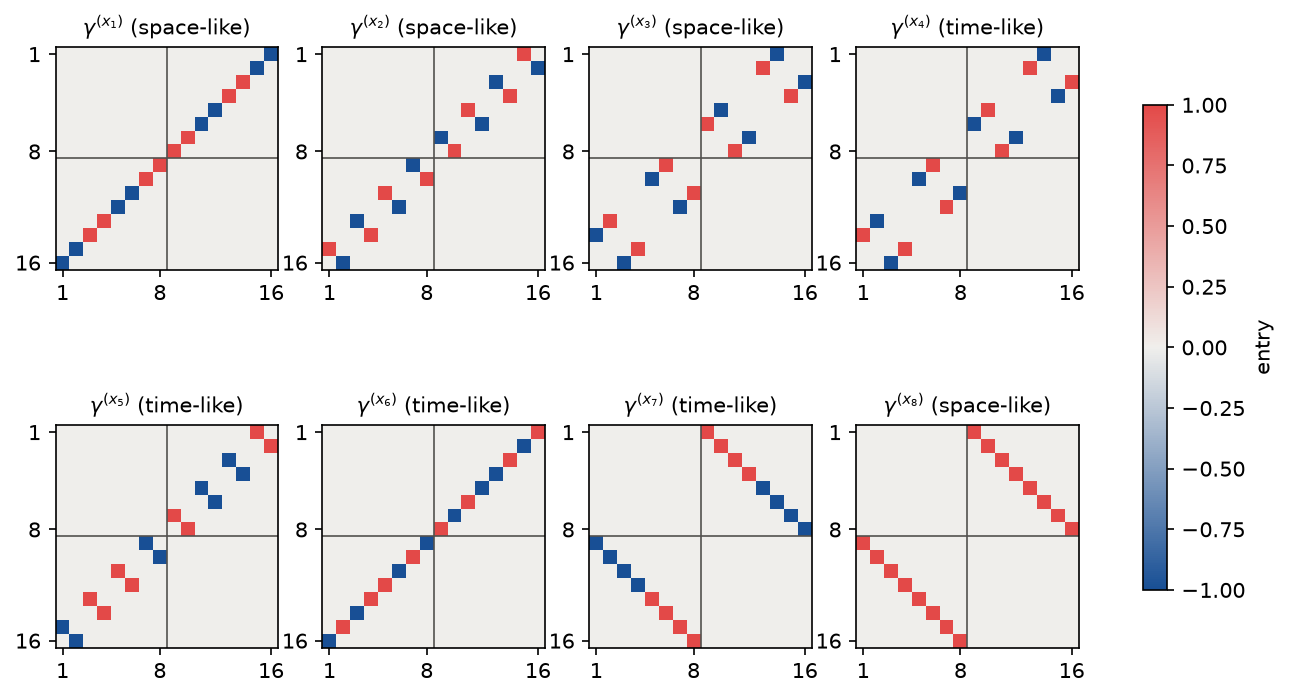

Figure 18a.1 saved as Revision/textbook/figures/18a_1_eight_gammas.png


In [4]:
from matplotlib.colors import LinearSegmentedColormap  # colour scales

BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_grey_red", ["#184f95", "#f0efec", "#e34948"])


def draw_matrix(ax, matrix, title, ticks=True):
    """Heat map of a real 16 x 16 matrix with entries between -1 and +1."""
    image = ax.imshow(matrix, cmap=DIVERGING, vmin=-1.0, vmax=1.0)
    places = [0, 7, 15] if ticks else []  # label rows and columns 1, 8, 16
    ax.set_xticks(places, [str(t + 1) for t in places])
    ax.set_yticks(places, [str(t + 1) for t in places])
    ax.axhline(7.5, color=GREY, linewidth=0.8)  # the border between the halves
    ax.axvline(7.5, color=GREY, linewidth=0.8)
    ax.grid(False)  # no grid lines on top of the squares
    ax.set_title(title, fontsize=10)
    return image


fig, axes = plt.subplots(2, 4, figsize=(11.0, 6.0))
for a, ax in zip([1, 2, 3, 4, 5, 6, 7, 8], axes.flat):
    kind = "space-like" if eta[a] == 1 else "time-like"
    image = draw_matrix(ax, gamma[a], f"$\\gamma^{{(x_{a})}}$ ({kind})")
fig.colorbar(image, ax=list(axes.flat), shrink=0.7, label="entry")
save_figure(fig, "eight_gammas",
            "The author's eight real 16 by 16 gamma matrices, one heat map each, in "
            "the order $x_1$ to $x_8$ of the author's coordinates (top row: "
            "$x_1, x_2, x_3, x_4$; bottom row: $x_5, x_6, x_7, x_8$). Horizontal "
            "axis: column number, vertical axis: row number; red is $+1$, blue is "
            "$-1$, light grey is 0; thin lines separate the components 1 to 8 "
            "from 9 to 16. Every row and every column holds exactly one red or "
            "blue square (signed permutation matrices), no entry is complex, and "
            "every matrix has its squares only in the two off-diagonal blocks, so "
            "each gamma exchanges the two halves of a 16-component field.")

The next cell builds $C$, $\Gamma$ and $B$ from the gammas and compares them with
the matrices stored in the same record. $B = -iC\gamma^{(x_4)}$ is $i$ times a real
whole-number matrix; the cell keeps that real matrix as `B_over_i` (so that
$B = i\,\cdot$ `B_over_i`) and also forms the complex matrix `B`. It checks the
basic facts used by the pairing record: $C$ real symmetric with $C^2 = 1$, every
$C\gamma^{(a)}$ antisymmetric, $B$ Hermitian with $B^2 = 1$, and
$C\gamma^{(x_4)} = iB$.

In [5]:
C = gamma[8] @ gamma[1] @ gamma[2] @ gamma[3]  # the four space-like gammas
Gamma = I16.copy()
for a in [8, 1, 2, 3, 4, 5, 6, 7]:  # the order of the factors of Gamma
    Gamma = Gamma @ gamma[a]
B_over_i = -(C @ gamma[4])  # B = -i C gamma^(x4) = i * (-C gamma^(x4))
B = 1j * B_over_i  # the complex matrix B (entries 0, +i, -i)
B_file = np.array(fixture["B"]["re"]) + 1j * np.array(fixture["B"]["im"])
stored = (same(C, np.array(fixture["C"])) and same(Gamma, np.array(fixture["Gamma"]))
          and np.array_equal(B, B_file))
reproduces(stored, "C, Gamma and B built here equal the matrices of the gammas record",
           (WL, ["fixture_definitions"]))
basic = (same(C.T, C) and same(C @ C, I16)
         and all(same((C @ gamma[a]).T, -(C @ gamma[a])) for a in range(1, 9))
         and np.array_equal(B.conj().T, B) and np.array_equal(B @ B, np.eye(16))
         and np.array_equal(C @ gamma[4], 1j * B))
reproduces(basic, "C real symmetric, C^2 = 1, B Hermitian, B^2 = 1, C gamma^(x4) = i B",
           (WL, ["C_and_B_basic"]), (PY, ["gammas.C", "gammas.B"]))

PASS C, Gamma and B built here equal the matrices of the gammas record
     reproduces Revision/pairing/reports/wolfram-pairing.json, check fixture_definitions
PASS C real symmetric, C^2 = 1, B Hermitian, B^2 = 1, C gamma^(x4) = i B
     reproduces Revision/pairing/reports/wolfram-pairing.json, check C_and_B_basic;
    Revision/pairing/reports/python-pairing.json, check gammas.C, gammas.B


## 6. Lemma 1: the chirality $\Gamma$

The next cell checks every part of Lemma 1 exactly: $\Gamma =
\mathrm{diag}(-I_8, I_8)$; $\Gamma$ is real and symmetric and $\Gamma^2 = 1$;
$\Gamma\gamma^{(a)} = -\gamma^{(a)}\Gamma$ for each of the eight gammas;
$\Gamma C = C\Gamma$; and $\Gamma S^{ab} = S^{ab}\Gamma$ for all 64 pairs
$(a, b)$. Since $S^{ab} = \frac14(\gamma^{(a)}\gamma^{(b)} -
\gamma^{(b)}\gamma^{(a)})$ has quarters and halves as entries, the cell uses
$4S^{ab}$, which has whole-number entries; $\Gamma$ commutes with $S^{ab}$ exactly
when it commutes with $4S^{ab}$.

Why these hold: $\Gamma$ is the product of all eight different gammas. Moving
$\gamma^{(b)}$ through it passes seven factors that anticommute with $\gamma^{(b)}$
and one ($\gamma^{(b)}$ itself) that commutes with it: the sign is $(-1)^7 = -1$.
$C$ (four gammas) and $S^{ab}$ (two gammas when $a \neq b$) contain an even number
of gammas, so $\Gamma$ passes them with the sign $(-1)^{\mathrm{even}} = +1$.

In [6]:
four_S = {(a, b): gamma[a] @ gamma[b] - gamma[b] @ gamma[a]  # 4 S^ab, whole numbers
          for a in range(1, 9) for b in range(1, 9)}
diagonal = same(Gamma, np.diag([-1] * 8 + [1] * 8))  # diag(-I8, I8)
real_symmetric_involution = same(Gamma.T, Gamma) and same(Gamma @ Gamma, I16)
anticommutes = all(same(Gamma @ gamma[a], -gamma[a] @ Gamma) for a in range(1, 9))
commutes_C = same(Gamma @ C, C @ Gamma)
commutes_S = all(same(Gamma @ M, M @ Gamma) for M in four_S.values())  # 64 pairs
say(f"Gamma = diag(-I8, I8): {diagonal}; real symmetric with Gamma^2 = 1: "
    f"{real_symmetric_involution}; anticommutes with all 8 gammas: {anticommutes}; "
    f"commutes with C: {commutes_C}; commutes with all 64 S^ab: {commutes_S}")
reproduces(diagonal and real_symmetric_involution and anticommutes and commutes_C
           and commutes_S, "Lemma 1: the chirality Gamma",
           (WL, ["Gamma_properties"]),
           (PY, ["gammas.Gamma", "gammas.Gamma_anticommutes"]))

Gamma = diag(-I8, I8): True; real symmetric with Gamma^2 = 1: True; anticommutes with all
    8 gammas: True; commutes with C: True; commutes with all 64 S^ab: True
PASS Lemma 1: the chirality Gamma
     reproduces Revision/pairing/reports/wolfram-pairing.json, check Gamma_properties;
    Revision/pairing/reports/python-pairing.json, check gammas.Gamma,
    gammas.Gamma_anticommutes


Lemma 1 says that $\Gamma$ commutes with EVERY spin connection
$\Omega_\mu = \frac12\sum_{a,b}\omega_{\mu ab}S^{ab}$, whatever the numbers
$\omega_{\mu ab}$ are, because it commutes with each $S^{ab}$. The next cell
illustrates this with numbers: it draws an arbitrary antisymmetric table
$\omega_{ab} = -\omega_{ba}$ of random numbers (with a fixed seed, so that every run
draws the same numbers), forms $\Omega = \frac12\sum_{a,b}\omega_{ab}S^{ab}$ and
measures the largest entry of $\Gamma\Omega - \Omega\Gamma$. This is an
illustration (floating-point numbers); the proof is the exact check above.

In [7]:
rng = np.random.default_rng(12345)  # a fixed seed: the same numbers every run
omega = rng.normal(size=(9, 9))  # rows and columns 1..8 are used (row 0 unused)
omega = omega - omega.T  # antisymmetric: omega[a, b] = -omega[b, a]
Omega = sum(0.5 * omega[a, b] * four_S[(a, b)] / 4.0
            for a in range(1, 9) for b in range(1, 9))  # (1/2) omega_ab S^ab
commutator = np.abs(Gamma @ Omega - Omega @ Gamma).max()
check(commutator < 1e-12 and np.abs(Omega).max() > 0.1,
      "Gamma commutes with a random spin connection Omega (largest entry of the "
      "commutator below 1e-12)")

PASS Gamma commutes with a random spin connection Omega (largest entry of the commutator
    below 1e-12)


The next cell draws three heat maps: $\Gamma$ (left), the gamma of the first
direction $\gamma^{(x_1)}$ (middle) and $\Gamma\gamma^{(x_1)}\Gamma$ (right). The
right picture is the middle one with every colour reversed: conjugating by
$\Gamma$ reverses the sign of a gamma. The cell first checks this for all eight
gammas.

PASS Gamma gamma^(a) Gamma = -gamma^(a) for all eight directions


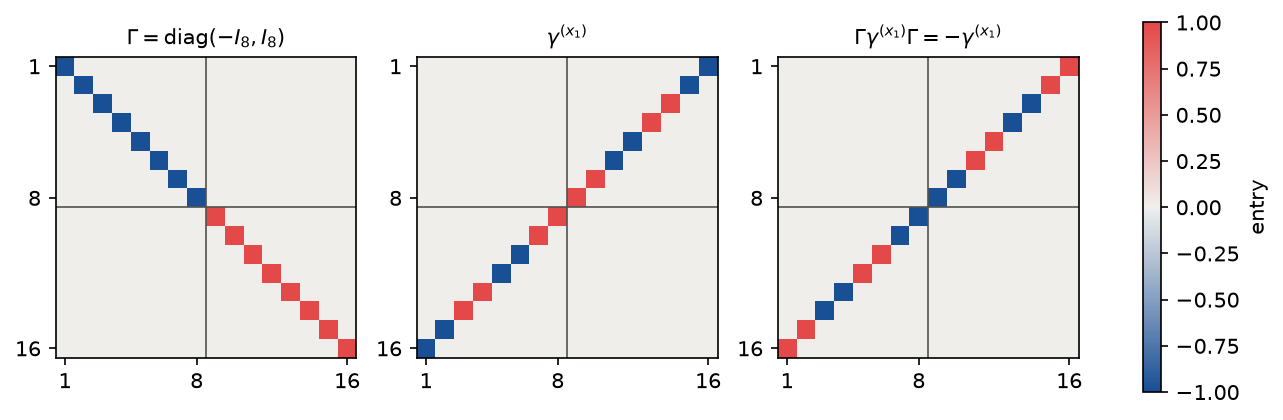

Figure 18a.2 saved as Revision/textbook/figures/18a_2_chirality_flips_gammas.png


In [8]:
flips = all(same(Gamma @ gamma[a] @ Gamma, -gamma[a]) for a in range(1, 9))
check(flips, "Gamma gamma^(a) Gamma = -gamma^(a) for all eight directions")
fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
draw_matrix(axes[0], Gamma, "$\\Gamma = \\mathrm{diag}(-I_8, I_8)$")
draw_matrix(axes[1], gamma[1], "$\\gamma^{(x_1)}$")
image = draw_matrix(axes[2], Gamma @ gamma[1] @ Gamma,
                    "$\\Gamma\\gamma^{(x_1)}\\Gamma = -\\gamma^{(x_1)}$")
fig.colorbar(image, ax=list(axes), shrink=0.8, label="entry")
save_figure(fig, "chirality_flips_gammas",
            "Heat maps of three 16 by 16 matrices: the chirality $\\Gamma$ (left), "
            "the gamma matrix $\\gamma^{(x_1)}$ of the first space direction "
            "(middle) and $\\Gamma\\gamma^{(x_1)}\\Gamma$ (right). Horizontal axis: "
            "column number, vertical axis: row number; red is $+1$, blue is $-1$, "
            "light grey is 0; thin lines separate the chiral halves, components 1 "
            "to 8 and 9 to 16. $\\Gamma$ is $-1$ on the first half and $+1$ on the "
            "second. $\\gamma^{(x_1)}$ has its entries only in the two off-diagonal "
            "blocks: it exchanges the halves. The right picture is the middle one "
            "with every colour reversed, because $\\Gamma$ anticommutes with every "
            "gamma. This sign is the whole content of the pairing theorem T1.")

## 7. Lemma 2: the sign of every bilinear under $\Psi \to \Gamma\Psi$

Section 4 showed that the map $\Psi \to \Gamma\Psi$ turns a bilinear
$\bar\Psi X\Psi$ into $\bar\Psi\,\Gamma X\Gamma\,\Psi$. The next cell forms all
$2^8 = 256$ products $X = \gamma^{(a_1)}\cdots\gamma^{(a_k)}$ of different gammas
($a_1 < \dots < a_k$, $k = 0, \dots, 8$; the empty product $k = 0$ is $I_{16}$),
determines for each the sign $s$ in $\Gamma X\Gamma = sX$, and checks that
$s = (-1)^k$ every time. It also counts the products of each length $k$; there are
$\binom{8}{k}$ of them (the number of ways to choose $k$ of 8 directions).

In [9]:
def sign_between(M, N):
    """+1 if M = N, -1 if M = -N, 0 otherwise (exact comparison)."""
    if same(M, N):
        return 1
    if same(M, -N):
        return -1
    return 0


parity_ok = True
counts = {k: {1: 0, -1: 0} for k in range(9)}  # k -> number of products per sign
for k in range(9):
    for subset in itertools.combinations(range(1, 9), k):
        X = I16.copy()
        for a in subset:  # the product gamma^(a1) ... gamma^(ak)
            X = X @ gamma[a]
        s = sign_between(Gamma @ X @ Gamma, X)
        parity_ok = parity_ok and s == (-1) ** k
        counts[k][s] += 1
say("number of products of k different gammas, by the sign s: "
    + "; ".join(f"k={k}: {counts[k][1]} with s=+1, {counts[k][-1]} with s=-1"
                for k in range(9)))
check(parity_ok and all(counts[k][1] + counts[k][-1] == comb(8, k) for k in range(9)),
      "Gamma X Gamma = (-1)^k X for all 256 products X of k different gammas")

number of products of k different gammas, by the sign s: k=0: 1 with s=+1, 0 with s=-1;
    k=1: 0 with s=+1, 8 with s=-1; k=2: 28 with s=+1, 0 with s=-1; k=3: 0 with s=+1, 56
    with s=-1; k=4: 70 with s=+1, 0 with s=-1; k=5: 0 with s=+1, 56 with s=-1; k=6: 28
    with s=+1, 0 with s=-1; k=7: 0 with s=+1, 8 with s=-1; k=8: 1 with s=+1, 0 with s=-1
PASS Gamma X Gamma = (-1)^k X for all 256 products X of k different gammas


The next cell checks the matrices that actually occur in the Lagrangian. Written
out with the vielbein $e^\mu{}_a$ and the connection $\omega_{\mu bc}$, the kinetic
term is

$$K = \frac12\sum_{\mu,a}e^\mu{}_a\big(\bar\Psi\gamma^{(a)}\partial_\mu\Psi -
\partial_\mu\bar\Psi\gamma^{(a)}\Psi\big) + \frac14\sum_{\mu,a,b,c}e^\mu{}_a
\omega_{\mu bc}\,\bar\Psi\{\gamma^{(a)}, S^{bc}\}\Psi ,$$

where $\{M, N\} = MN + NM$. As bilinears in $\Psi^\dagger$ and $\Psi$ their kernels
are $C\gamma^{(a)}$ (8 matrices) and $C\gamma^{(a)}S^{bc}$, $CS^{bc}\gamma^{(a)}$
with $b < c$ (224 each): 456 matrices in all, the list of the sympy verifier.
Since $\Gamma$ is real and symmetric, the kernel $X$ of $\Psi^\dagger X\Psi$
becomes $\Gamma^TX\Gamma = \Gamma X\Gamma$. The cell checks $\Gamma X\Gamma = -X$
for all 456 kernels and $\Gamma C\Gamma = +C$ for the kernel of $S$. It also checks
the form used by the Wolfram verifier, $\Gamma C\{\gamma^{(a)}, S^{bc}\}\Gamma =
-C\{\gamma^{(a)}, S^{bc}\}$ for all $8^3 = 512$ triples $(a, b, c)$, the
field-equation kernels $\Gamma\gamma^{(a)}\Gamma = -\gamma^{(a)}$ and
$\Gamma S^{bc}\Gamma = S^{bc}$, and $\Gamma B\Gamma = -B$ (the last part of
Lemma 2). Products with $S^{bc}$ are formed with $4S^{bc}$ (whole numbers).

In [10]:
kinetic = [C @ gamma[a] for a in range(1, 9)]
connection = [C @ gamma[a] @ four_S[(b, c)] for a in range(1, 9)
              for b in range(1, 9) for c in range(b + 1, 9)]
connection += [C @ four_S[(b, c)] @ gamma[a] for a in range(1, 9)
               for b in range(1, 9) for c in range(b + 1, 9)]
kernels = kinetic + connection
all_flip = all(same(Gamma @ X @ Gamma, -X) for X in kernels)
scalar_kept = same(Gamma @ C @ Gamma, C)
triples = [C @ (gamma[a] @ four_S[(b, c)] + four_S[(b, c)] @ gamma[a])
           for a in range(1, 9) for b in range(1, 9) for c in range(1, 9)]
triples_flip = all(same(Gamma @ X @ Gamma, -X) for X in triples)
field_kernels = (all(same(Gamma @ gamma[a] @ Gamma, -gamma[a]) for a in range(1, 9))
                 and all(same(Gamma @ M @ Gamma, M) for M in four_S.values()))
krein_reversed = np.array_equal(Gamma @ B @ Gamma, -B)
report("number of kinetic and connection kernels", len(kernels))
report("number of triples (a, b, c)", len(triples))
reproduces(len(kernels) == 456 and all_flip and scalar_kept,
           "Lemma 2: all 456 kinetic and connection kernels flip, C is kept",
           (PY, ["T1.general_field.matrix_identities"]),
           (WL, ["T1_kernel_scalar", "T1_kernel_kinetic"]))
reproduces(len(triples) == 512 and triples_flip and field_kernels and krein_reversed,
           "Lemma 2: 512 connection triples flip; field-equation kernels; GBG = -B",
           (WL, ["T1_kernel_connection", "T1_kernel_field_equation"]),
           (PY, ["Q.image_krein_metric"]))

RESULT number of kinetic and connection kernels = 456
RESULT number of triples (a, b, c) = 512
PASS Lemma 2: all 456 kinetic and connection kernels flip, C is kept
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.general_field.matrix_identities; Revision/pairing/reports/wolfram-pairing.json,
    check T1_kernel_scalar, T1_kernel_kinetic
PASS Lemma 2: 512 connection triples flip; field-equation kernels; GBG = -B
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    T1_kernel_connection, T1_kernel_field_equation; Revision/pairing/reports/python-
    pairing.json, check Q.image_krein_metric


The next cell draws the result of the 256 products as a bar chart: for each number
$k$ of gamma factors, a bar of height $\binom{8}{k}$ (the number of such products),
red when the bilinear keeps its sign under $\Psi \to \Gamma\Psi$ ($k$ even) and
blue when it changes sign ($k$ odd). Labels name the bilinears of the theory that
belong to some of the bars.

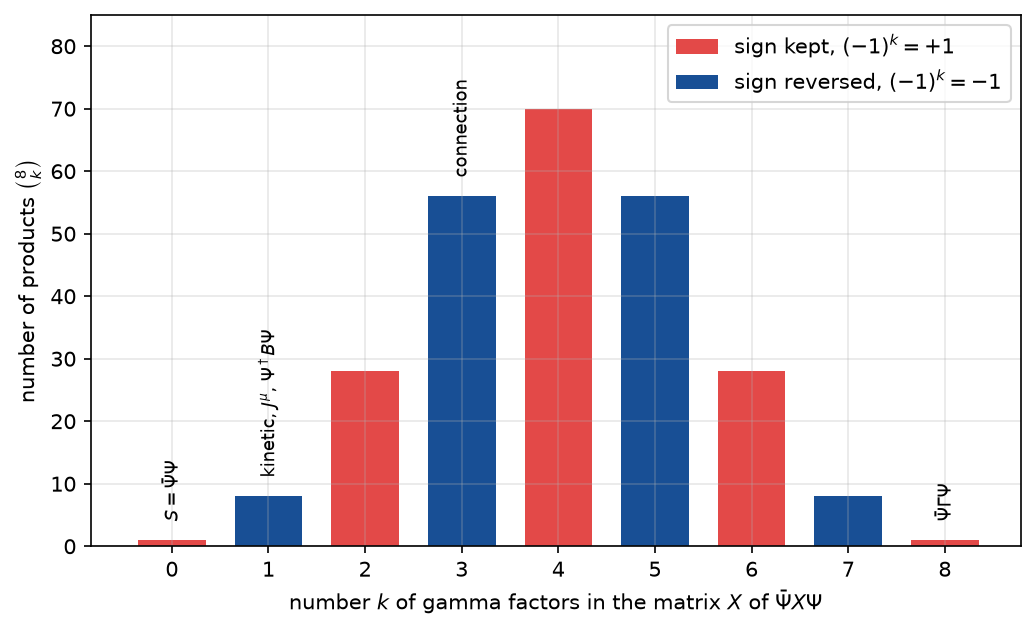

Figure 18a.3 saved as Revision/textbook/figures/18a_3_parity_of_products.png


In [11]:
ks = np.arange(9)
heights = [comb(8, int(k)) for k in ks]
colours = ["#e34948" if k % 2 == 0 else "#184f95" for k in ks]
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.bar(ks, heights, color=colours, width=0.7)
ax.set_xticks(ks)
ax.set_xlabel("number $k$ of gamma factors in the matrix $X$ of $\\bar\\Psi X\\Psi$")
ax.set_ylabel("number of products $\\binom{8}{k}$")
ax.set_ylim(0, 85)
notes = {0: "$S = \\bar\\Psi\\Psi$", 1: "kinetic, $J^\\mu$, $\\Psi^\\dagger B\\Psi$",
         3: "connection", 8: "$\\bar\\Psi\\Gamma\\Psi$"}
for k, text in notes.items():
    ax.text(k, heights[k] + 3, text, ha="center", fontsize=8.5, rotation=90,
            va="bottom")
ax.bar([0], [0], color="#e34948", label="sign kept, $(-1)^k = +1$")
ax.bar([0], [0], color="#184f95", label="sign reversed, $(-1)^k = -1$")
ax.legend(loc="upper right")
save_figure(fig, "parity_of_products",
            "The 256 products $X$ of different gamma matrices, sorted by the number "
            "$k$ of factors (horizontal axis); the bar height is the number of "
            "such products, $\\binom{8}{k}$ (vertical axis). Red bars: the "
            "bilinear $\\bar\\Psi X\\Psi$ keeps its value under the chirality map "
            "$\\Psi \\to \\Gamma\\Psi$; blue bars: it changes sign. The sign is "
            "$(-1)^k$ for every one of the 256 products. The scalar $S$ sits in "
            "the red bar $k = 0$; the kinetic terms, the current $J^\\mu$ and the "
            "charge density $\\Psi^\\dagger B\\Psi$ in the blue bar $k = 1$; the "
            "spin-connection terms in the blue bar $k = 3$. This is why T1 "
            "reverses the kinetic term but not the mass term.")

## 8. Lemma 3: the eight reflections and their Pin(4,4) lifts

For each direction $n = x_1, \dots, x_8$ the next cell forms $P_n = \Gamma
\gamma^{(n)}$ and checks, exactly:

1. $P_n$ equals $+$ or $-$ the product of the other seven gammas in the order of
   $\Gamma$ ($x_8, x_1, \dots, x_7$ without $n$), so it is a product of unit
   vectors and lies in Pin(4,4); the signs are recorded.
2. $P_n$ is a signed permutation matrix, so $P_n^{-1} = P_n^T$, and
   $P_n^{-1}\gamma^{(a)}P_n = (R_n)_{aa}\gamma^{(a)}$ for all $a$: $P_n$ acts on the
   gammas exactly as the reflection $R_n$ of the direction $n$.
3. The character: $P_n^\dagger CP_n = \chi_nC$ with $\chi_n = -\eta_{nn}$.
4. $\Gamma P_n = \gamma^{(n)}$ (because $\Gamma\Gamma = 1$): "$\Gamma$ combined with
   the reflection $P_n$" acts on the field as the single matrix $\gamma^{(n)}$.
5. For $M = \gamma^{(n)}$ together with the reflected frame: the scalar sign
   $M^TCM = -\eta_{nn}C$; the kinetic kernels $M^TC\gamma^{(a)}M =
   \eta_{nn}(R_n)_{aa}C\gamma^{(a)}$ (the factor $(R_n)_{aa}$ is absorbed by the
   reflected frame, so the kinetic term gets the sign $\eta_{nn}$); and the 512
   connection kernels $M^TC\{\gamma^{(a)}, S^{bc}\}M = \eta_{nn}(R_n)_{aa}
   (R_n)_{bb}(R_n)_{cc}C\{\gamma^{(a)}, S^{bc}\}$ (the connection of the reflected
   frame is $R_n\omega R_n$, which absorbs the other two factors).

From items 3 and 5: for a space-like $n$ the kinetic term is unchanged and $S$
changes sign, so $\mathcal{L}_{m,\lambda} \to \mathcal{L}_{-m,\lambda}$ (T2); for a
time-like $n$ the kinetic term changes sign and $S$ does not, so
$\mathcal{L}_{m,\lambda} \to -\mathcal{L}_{-m,-\lambda}$ (a map of the T1 type).

In [12]:
order = [8, 1, 2, 3, 4, 5, 6, 7]  # the order of the factors of Gamma
names = {a: f"x{a}" for a in range(1, 9)}
rows = []  # one row of the reflection table per direction n
lemma3_ok = True
for n in range(1, 9):
    P = Gamma @ gamma[n]
    others = I16.copy()
    for a in order:
        if a != n:
            others = others @ gamma[a]  # the product of the other seven gammas
    R = {a: (-1 if a == n else 1) for a in range(1, 9)}  # the diagonal of R_n
    orthogonal = same(P.T @ P, I16)  # so P^-1 = P^T
    covers = all(same(P.T @ gamma[a] @ P, R[a] * gamma[a]) for a in range(1, 9))
    M = gamma[n]  # Gamma P_n = gamma^(n)
    kinetic_sign = eta[n]
    kinetic_ok = all(same(M.T @ C @ gamma[a] @ M, kinetic_sign * R[a] * C @ gamma[a])
                     for a in range(1, 9))
    connection_ok = all(
        same(M.T @ C @ (gamma[a] @ four_S[(b, c)] + four_S[(b, c)] @ gamma[a]) @ M,
             kinetic_sign * R[a] * R[b] * R[c]
             * C @ (gamma[a] @ four_S[(b, c)] + four_S[(b, c)] @ gamma[a]))
        for a in range(1, 9) for b in range(1, 9) for c in range(1, 9))
    row = {"direction": names[n], "eta_nn": eta[n],
           "product_sign": sign_between(P, others),
           "character": sign_between(P.T @ C @ P, C),
           "S_sign": sign_between(M.T @ C @ M, C),
           "kinetic_sign": kinetic_sign if kinetic_ok else 0}
    row["map"] = ("(m, lambda) -> (-m, lambda), L -> +L (T2)"
                  if (row["S_sign"], row["kinetic_sign"]) == (-1, 1)
                  else "(m, lambda) -> (-m, -lambda), L -> -L (T1-type)")
    rows.append(row)
    lemma3_ok = (lemma3_ok and orthogonal and covers and connection_ok and kinetic_ok
                 and same(Gamma @ P, gamma[n]) and row["character"] == -eta[n]
                 and row["product_sign"] in (1, -1))
for row in rows:
    say(f"{row['direction']}: eta {row['eta_nn']:+d}, P_n = {row['product_sign']:+d} "
        f"x (other seven), character {row['character']:+d}, S -> "
        f"{row['S_sign']:+d} S, kinetic {row['kinetic_sign']:+d}: {row['map']}")
product_signs = [r["product_sign"] for r in rows]
reproduces(lemma3_ok and product_signs == [1, -1, 1, 1, -1, 1, -1, -1],
           "Lemma 3: P_n in Pin(4,4), covers R_n, character -eta_nn, Gamma P_n = g^n",
           (WL, ["T2_Pn_in_Pin44", "T2_Pn_covers_the_reflection", "T2_character_of_Pn",
                 "T2_Gamma_times_Pn_is_gamma_n",
                 "T2_kernels_gamma_n_with_frame_reflection"]),
           (PY, ["T2.general_field.matrix_identities",
                 "T2.general_field.reflection_table"]))

x1: eta +1, P_n = +1 x (other seven), character -1, S -> -1 S, kinetic +1: (m, lambda) ->
    (-m, lambda), L -> +L (T2)
x2: eta +1, P_n = -1 x (other seven), character -1, S -> -1 S, kinetic +1: (m, lambda) ->
    (-m, lambda), L -> +L (T2)
x3: eta +1, P_n = +1 x (other seven), character -1, S -> -1 S, kinetic +1: (m, lambda) ->
    (-m, lambda), L -> +L (T2)
x4: eta -1, P_n = +1 x (other seven), character +1, S -> +1 S, kinetic -1: (m, lambda) ->
    (-m, -lambda), L -> -L (T1-type)
x5: eta -1, P_n = -1 x (other seven), character +1, S -> +1 S, kinetic -1: (m, lambda) ->
    (-m, -lambda), L -> -L (T1-type)
x6: eta -1, P_n = +1 x (other seven), character +1, S -> +1 S, kinetic -1: (m, lambda) ->
    (-m, -lambda), L -> -L (T1-type)
x7: eta -1, P_n = -1 x (other seven), character +1, S -> +1 S, kinetic -1: (m, lambda) ->
    (-m, -lambda), L -> -L (T1-type)
x8: eta +1, P_n = -1 x (other seven), character -1, S -> -1 S, kinetic +1: (m, lambda) ->
    (-m, lambda), L -> +L (T2)
PASS Lem

The next cell compares the table just computed with the data table `reflections`
of the Revision record `Revision/pairing/pairing-theory.json`, field by field
(the sign of $\eta_{nn}$, the sign of $P_n$ against the product of the other seven,
the character, the sign of $S$, the kinetic sign and the resulting map of the mass
and the coupling). It also reads the status line of the record, which must say
that all checks of its report passed.

In [13]:
theory = read_json(THEORY)
recorded_rows = theory["data"]["reflections"]
keys = [("eta_nn", "eta_nn"),
        ("product_sign", "P_n_equals_sign_times_product_of_other_seven"),
        ("character", "character_of_P_n"), ("S_sign", "S_sign_under_gamma_n"),
        ("kinetic_sign", "kinetic_sign_under_gamma_n_with_frame_reflection"),
        ("map", "mass_coupling_map")]
table_equal = len(recorded_rows) == 8 and all(
    recorded["direction"] == mine["direction"]
    and all(mine[k_mine] == recorded[k_rec] for k_mine, k_rec in keys)
    for mine, recorded in zip(rows, recorded_rows))
say("status of the theory record: " + theory["status"])
reproduces(table_equal and theory["status"] == "all checks of the report passed",
           "the reflection table equals the record's, row by row",
           (PY, ["compare.theory.reflection_table"]), table="reflections")

status of the theory record: all checks of the report passed
PASS the reflection table equals the record's, row by row
     reproduces Revision/pairing/pairing-theory.json, data table reflections;
    Revision/pairing/reports/python-pairing.json, check compare.theory.reflection_table


The next cell draws the reflection table: eight rows (the directions), five
columns of signs (red $+1$, blue $-1$) and, at the right, the map that the row
produces.

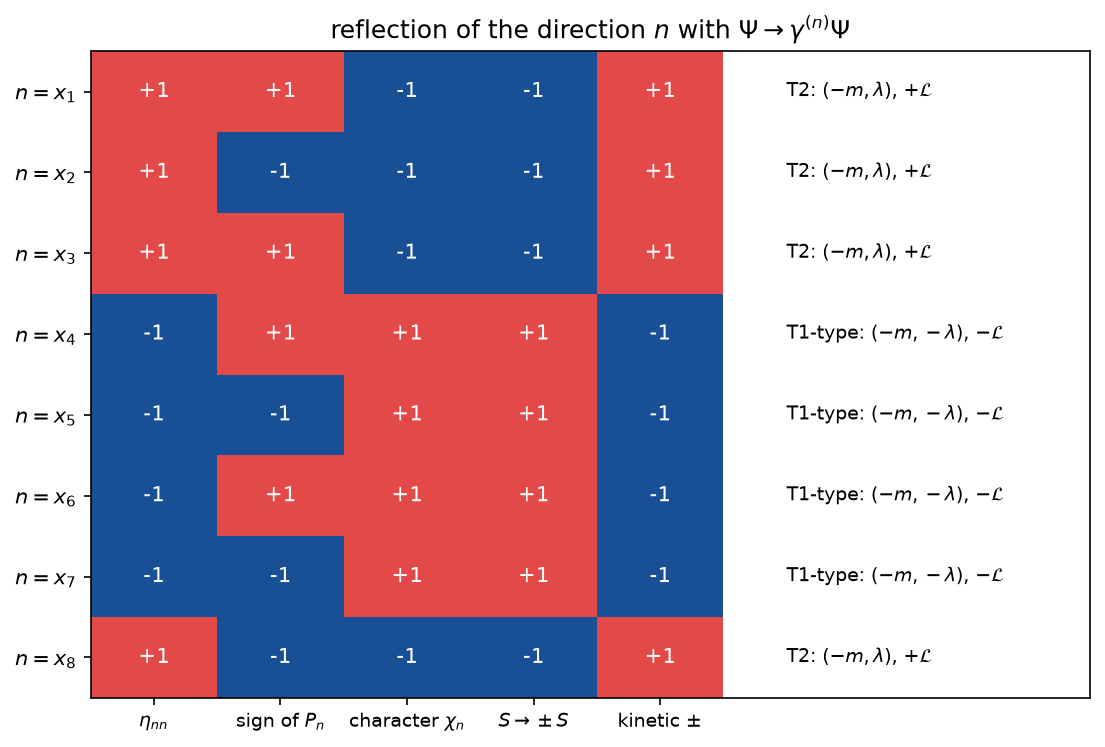

Figure 18a.4 saved as Revision/textbook/figures/18a_4_reflection_table.png


In [14]:
columns = ["$\\eta_{nn}$", "sign of $P_n$", "character $\\chi_n$",
           "$S \\to \\pm S$", "kinetic $\\pm$"]
grid = np.array([[r["eta_nn"], r["product_sign"], r["character"], r["S_sign"],
                  r["kinetic_sign"]] for r in rows], dtype=float)
fig, ax = plt.subplots(figsize=(8.6, 5.6))
ax.imshow(grid, cmap=DIVERGING, vmin=-1.0, vmax=1.0, aspect="auto")
for i in range(8):
    for j in range(5):
        ax.text(j, i, f"{int(grid[i, j]):+d}", ha="center", va="center",
                color="white", fontsize=10)
    label = "T2: $(-m, \\lambda)$, $+\\mathcal{L}$" if rows[i]["S_sign"] == -1 \
        else "T1-type: $(-m, -\\lambda)$, $-\\mathcal{L}$"
    ax.text(5.0, i, label, ha="left", va="center", fontsize=9)
ax.set_xticks(range(5), columns, fontsize=9)
ax.set_yticks(range(8), [f"$n = x_{a}$" for a in range(1, 9)])
ax.set_xlim(-0.5, 7.4)
ax.grid(False)
ax.set_title("reflection of the direction $n$ with $\\Psi \\to \\gamma^{(n)}\\Psi$")
save_figure(fig, "reflection_table",
            "The reflection table of Lemma 3, one row for each direction $n$ (the "
            "space-like $x_1, x_2, x_3, x_8$ and the time-like $x_4$ to $x_7$). "
            "Columns: the sign $\\eta_{nn}$ of the direction; the sign of "
            "$P_n = \\Gamma\\gamma^{(n)}$ relative to the product of the other "
            "seven gammas; the character $\\chi_n$ in $P_n^\\dagger CP_n = "
            "\\chi_nC$; the sign of $S$ and of the kinetic term under "
            "$\\Psi \\to \\gamma^{(n)}\\Psi$ with the reflected frame. Red is "
            "$+1$, blue is $-1$. The character is always $-\\eta_{nn}$. A "
            "space-like reflection keeps the kinetic term and reverses $S$: the "
            "mass changes sign and the coupling does not (theorem T2). A "
            "time-like reflection does the opposite, which gives a map of the T1 "
            "type. The table equals the Revision record row by row.")

## 9. The chiral projectors and the two halves

The author's notebook also defines the two *chiral projectors*
$P_L = \frac12(1 - \Gamma)$ and $P_R = \frac12(1 + \Gamma)$; we write them
$P_- = P_L$ and $P_+ = P_R$. Since $\Gamma = \mathrm{diag}(-I_8, I_8)$,
$P_- = \mathrm{diag}(I_8, 0)$ keeps the components 1 to 8 ($\psi_-$) and $P_+ =
\mathrm{diag}(0, I_8)$ keeps 9 to 16 ($\psi_+$). The next cell checks, exactly:

- $P_\pm^2 = P_\pm$ (projectors), $P_- + P_+ = 1$, $P_-P_+ = 0$, each of rank 8;
- $\Gamma = P_+ - P_-$: the T1 image is $\Gamma\Psi = P_+\Psi - P_-\Psi$, the field
  with the relative sign of its two halves reversed;
- $\gamma^{(a)}P_- = P_+\gamma^{(a)}$ for all eight gammas: a gamma takes the
  $\psi_-$ half into the $\psi_+$ half (and back), because it anticommutes with
  $\Gamma$;
- $CP_\pm = P_\pm C$ and $S^{ab}P_\pm = P_\pm S^{ab}$: $C$ and the generators of
  Spin(4,4) keep each half, which is why the two halves are separate
  representations of Spin(4,4).

projectors of rank 8: True; Gamma = P+ - P-: True; every gamma maps the minus half to the
    plus half: True; C and all S^ab keep each half: True
PASS the chiral projectors: P-^2 = P-, P+^2 = P+, Gamma = P+ - P-, gammas swap


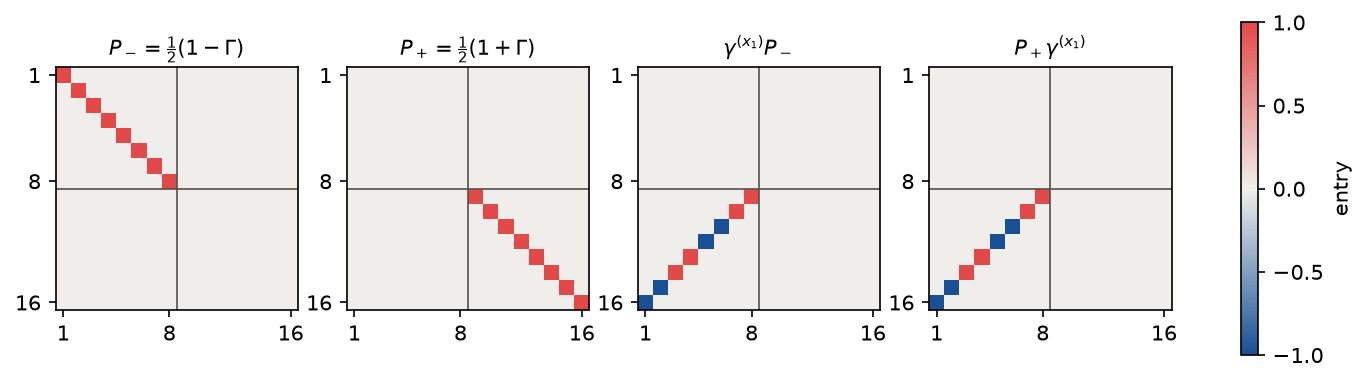

Figure 18a.5 saved as Revision/textbook/figures/18a_5_chiral_projectors.png


In [15]:
P_minus = (I16 - Gamma) // 2  # whole numbers 0 and 1: the author's P_L
P_plus = (I16 + Gamma) // 2  # the author's P_R
projectors = (same(P_minus @ P_minus, P_minus) and same(P_plus @ P_plus, P_plus)
              and same(P_minus + P_plus, I16) and not (P_minus @ P_plus).any()
              and int(np.trace(P_minus)) == 8 and int(np.trace(P_plus)) == 8)
gamma_is_difference = same(Gamma, P_plus - P_minus)
gammas_swap = all(same(gamma[a] @ P_minus, P_plus @ gamma[a]) for a in range(1, 9))
halves_kept = (same(C @ P_minus, P_minus @ C)
               and all(same(M @ P_minus, P_minus @ M) for M in four_S.values()))
say(f"projectors of rank 8: {projectors}; Gamma = P+ - P-: {gamma_is_difference}; "
    f"every gamma maps the minus half to the plus half: {gammas_swap}; C and all "
    f"S^ab keep each half: {halves_kept}")
check(projectors and gamma_is_difference and gammas_swap and halves_kept,
      "the chiral projectors: P-^2 = P-, P+^2 = P+, Gamma = P+ - P-, gammas swap")
fig, axes = plt.subplots(1, 4, figsize=(12.0, 3.6))
draw_matrix(axes[0], P_minus, "$P_- = \\frac{1}{2}(1 - \\Gamma)$")
draw_matrix(axes[1], P_plus, "$P_+ = \\frac{1}{2}(1 + \\Gamma)$")
draw_matrix(axes[2], gamma[1] @ P_minus, "$\\gamma^{(x_1)}P_-$")
image = draw_matrix(axes[3], P_plus @ gamma[1], "$P_+\\gamma^{(x_1)}$")
fig.colorbar(image, ax=list(axes), shrink=0.8, label="entry")
save_figure(fig, "chiral_projectors",
            "Heat maps of the two chiral projectors and of one gamma between them; "
            "columns horizontal, rows vertical, red $+1$, blue $-1$, grey 0, thin "
            "lines between the halves. $P_-$ (first picture, the author's P_L) is "
            "the identity on the components 1 to 8 and zero elsewhere; $P_+$ "
            "(second, the author's P_R) is the identity on 9 to 16. Their "
            "difference is $\\Gamma$. The third and fourth pictures are equal: "
            "$\\gamma^{(x_1)}P_- = P_+\\gamma^{(x_1)}$, so the gamma takes a field "
            "that lives in the first half into the second half. The T1 image "
            "$\\Gamma\\Psi = P_+\\Psi - P_-\\Psi$ reverses the relative sign of "
            "the two halves.")

The next cell checks the block form behind the theorems. Split
$\Psi = (\psi_-, \psi_+)$ into its first and second eight components. Then

- $\Gamma(\psi_-, \psi_+) = (-\psi_-, \psi_+)$: the T1 image reverses the
  relative sign of the two halves;
- every gamma has nonzero entries only in the two off-diagonal $8 \times 8$ blocks
  (it exchanges the halves), and $\gamma^{(x_8)}$ has the identity $I_8$ in both
  of them, so $\gamma^{(x_8)}(\psi_-, \psi_+) = (\psi_+, \psi_-)$: the T2 image
  exchanges the two halves;
- $C$ (a product of four gammas, an even number of exchanges) is block diagonal,
  $C = \mathrm{diag}(-\sigma, \sigma)$ with an $8 \times 8$ matrix $\sigma$, so
  $S = -\psi_-^\dagger\sigma\psi_- + \psi_+^\dagger\sigma\psi_+$. Exchanging the
  halves therefore reverses $S$, and reversing one half keeps $S$.

every gamma off-diagonal: True; gamma^(x8) = [[0, I8], [I8, 0]]: True; C = diag(-sigma,
    sigma): True
PASS block form: gammas exchange the halves, gamma^(x8) swaps them, C is diagonal


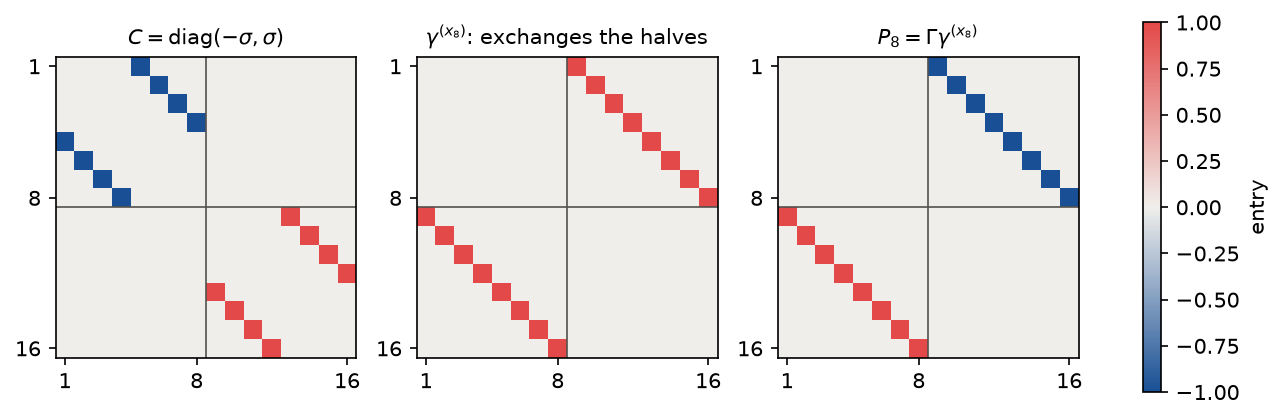

Figure 18a.6 saved as Revision/textbook/figures/18a_6_chiral_blocks.png


In [16]:
def blocks(M):
    """The four 8 x 8 blocks of a 16 x 16 matrix: upper left, upper right, lower
    left, lower right."""
    return M[:8, :8], M[:8, 8:], M[8:, :8], M[8:, 8:]


off_diagonal = all(not blocks(gamma[a])[0].any() and not blocks(gamma[a])[3].any()
                   for a in range(1, 9))  # .any() is False when all entries are 0
g8_swaps = (same(blocks(gamma[8])[1], I8) and same(blocks(gamma[8])[2], I8))
C_ul, C_ur, C_ll, C_lr = blocks(C)
C_block_diagonal = not C_ur.any() and not C_ll.any() and same(C_ul, -C_lr)
P8 = Gamma @ gamma[8]
say(f"every gamma off-diagonal: {off_diagonal}; gamma^(x8) = [[0, I8], [I8, 0]]: "
    f"{g8_swaps}; C = diag(-sigma, sigma): {C_block_diagonal}")
check(off_diagonal and g8_swaps and C_block_diagonal,
      "block form: gammas exchange the halves, gamma^(x8) swaps them, C is diagonal")
fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
draw_matrix(axes[0], C, "$C = \\mathrm{diag}(-\\sigma, \\sigma)$")
draw_matrix(axes[1], gamma[8], "$\\gamma^{(x_8)}$: exchanges the halves")
image = draw_matrix(axes[2], P8, "$P_8 = \\Gamma\\gamma^{(x_8)}$")
fig.colorbar(image, ax=list(axes), shrink=0.8, label="entry")
save_figure(fig, "chiral_blocks",
            "Heat maps of $C$ (left), $\\gamma^{(x_8)}$ (middle) and the reflection "
            "$P_8 = \\Gamma\\gamma^{(x_8)}$ of the hidden direction (right); axes "
            "as in the first figure (columns horizontal, rows vertical, red $+1$, "
            "blue $-1$, grey 0), thin lines between the chiral halves. $C$ lives "
            "in the two diagonal blocks, with opposite signs: "
            "$S = -\\psi_-^\\dagger\\sigma\\psi_- + \\psi_+^\\dagger\\sigma\\psi_+$. "
            "$\\gamma^{(x_8)}$ is the identity in both off-diagonal blocks: it "
            "exchanges $\\psi_-$ and $\\psi_+$, which reverses $S$ (the T2 image). "
            "$P_8$ differs from $\\gamma^{(x_8)}$ by the sign of one block, the "
            "work of $\\Gamma$.")

## 10. Lemma 4: the Krein signs of the 17 maps

For the quantised field dirac16complex the canonical anticommutator is
$\{\Psi_A, \Psi_B^\dagger\} = B_{AB}\,\delta/\sqrt{|g|}$. For the image field
$M\Psi$ it becomes $(MBM^\dagger)_{AB}\,\delta/\sqrt{|g|}$. The next cell computes
the sign $\sigma$ in $MBM^\dagger = \sigma B$ for the 17 maps $M = \Gamma$,
$M = \gamma^{(n)}$ and $M = P_n$, and compares the list with the data table
`Krein_signs_M_B_Mdagger` of the pairing record. It uses $B = i\,$`B_over_i`:
$MBM^\dagger = i\,M\,$`B_over_i`$\,M^T$ for a real $M$, so whole numbers suffice.

In [17]:
maps = [("Gamma", Gamma)]
maps += [(f"gamma^x{n}", gamma[n]) for n in range(1, 9)]
maps += [(f"P_x{n}", Gamma @ gamma[n]) for n in range(1, 9)]
krein = {name: sign_between(M @ B_over_i @ M.T, B_over_i) for name, M in maps}
say("M B M^dagger = sigma B: " + ", ".join(f"{name} {s:+d}"
                                           for name, s in krein.items()))
recorded_krein = {row["map"]: row["sign"]
                  for row in theory["data"]["Krein_signs_M_B_Mdagger"]}
reproduces(krein == recorded_krein and krein["Gamma"] == -1 and krein["gamma^x8"] == 1,
           "Lemma 4: the 17 Krein signs equal the record's; Gamma -1, gamma^(x8) +1",
           (WL, ["Q_Krein_metric_of_images"]),
           (PY, ["compare.theory.krein_signs", "Q.T2_image_keeps_B"]),
           table="Krein_signs_M_B_Mdagger")

M B M^dagger = sigma B: Gamma -1, gamma^x1 +1, gamma^x2 +1, gamma^x3 +1, gamma^x4 +1,
    gamma^x5 -1, gamma^x6 -1, gamma^x7 -1, gamma^x8 +1, P_x1 -1, P_x2 -1, P_x3 -1, P_x4
    -1, P_x5 +1, P_x6 +1, P_x7 +1, P_x8 -1
PASS Lemma 4: the 17 Krein signs equal the record's; Gamma -1, gamma^(x8) +1
     reproduces Revision/pairing/pairing-theory.json, data table Krein_signs_M_B_Mdagger;
    Revision/pairing/reports/wolfram-pairing.json, check Q_Krein_metric_of_images;
    Revision/pairing/reports/python-pairing.json, check compare.theory.krein_signs,
    Q.T2_image_keeps_B


The next cell draws the imaginary parts of $B$, of $\Gamma B\Gamma^\dagger$ and of
$\gamma^{(x_8)}B\gamma^{(x_8)\dagger}$ (all three are purely imaginary). The image
under $\Gamma$ (the T1 map) carries $-B$; the image under $\gamma^{(x_8)}$ (the T2
map) carries $+B$.

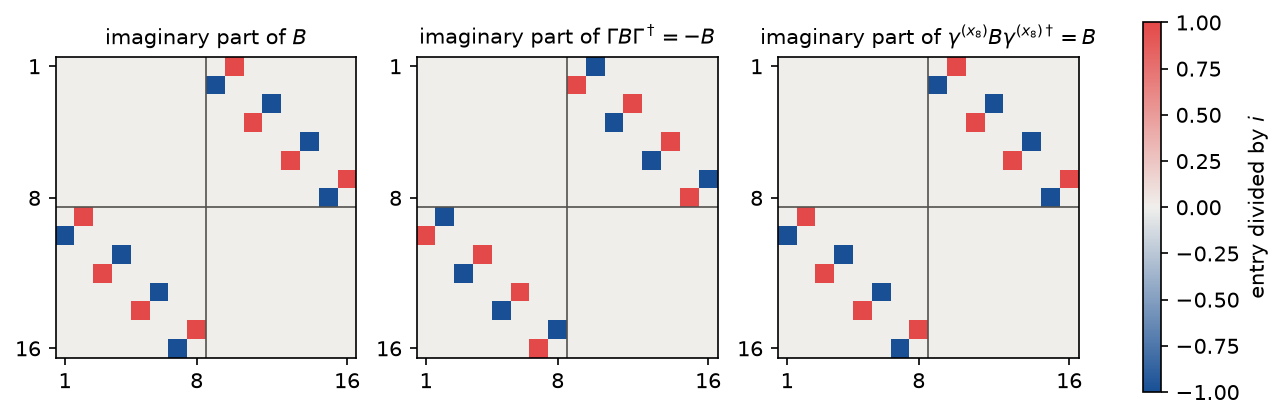

Figure 18a.7 saved as Revision/textbook/figures/18a_7_krein_signs.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
draw_matrix(axes[0], B_over_i, "imaginary part of $B$")
draw_matrix(axes[1], Gamma @ B_over_i @ Gamma.T,
            "imaginary part of $\\Gamma B\\Gamma^\\dagger = -B$")
image = draw_matrix(axes[2], gamma[8] @ B_over_i @ gamma[8].T,
                    "imaginary part of $\\gamma^{(x_8)}B\\gamma^{(x_8)\\dagger} = B$")
fig.colorbar(image, ax=list(axes), shrink=0.8, label="entry divided by $i$")
save_figure(fig, "krein_signs",
            "Heat maps of the imaginary parts of three 16 by 16 matrices (their "
            "real parts are zero): the Krein matrix $B = -iC\\gamma^{(x_4)}$ (left), "
            "$\\Gamma B\\Gamma^\\dagger$ (middle) and "
            "$\\gamma^{(x_8)}B\\gamma^{(x_8)\\dagger}$ (right); columns horizontal, "
            "rows vertical, red $+1$, blue $-1$, grey 0. The middle picture is the "
            "left one with all colours reversed: the chirality image "
            "$\\Gamma\\Psi$ of a quantised field has the anticommutator $-B$. The "
            "right picture equals the left one: the mirror image "
            "$\\gamma^{(x_8)}\\Psi$ of theorem T2 keeps $+B$, so it is an ordinary "
            "copy of the theory with equal energies.")

## 11. The last check

The last cell checks that the seven figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [19]:
figure_names = ["eight_gammas", "chirality_flips_gammas", "parity_of_products",
                "reflection_table", "chiral_projectors", "chiral_blocks",
                "krein_signs"]
paths = [output_file(f"{FIGURE_FOLDER}/18a_{k}_{name}.png")
         for k, name in enumerate(figure_names, 1)]
check(all(path.is_file() for path in paths),
      "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 16 CHECKS PASSED (notebook 18a)


## 12. What this notebook showed

- PROVED (exact whole-number comparison): the eight matrices used by the Revision
  record, and by every notebook of this chapter, are the author's own: they are
  real $16 \times 16$ signed permutation matrices with entries $-1, 0, +1$, they
  obey the 64 Clifford relations of signature (4,4), and they equal the matrices
  T16A[0..7] rebuilt here from the author's formulas, in the author's coordinates
  $x_1, \dots, x_8$.
- PROVED (exact whole-number identities of the author's gammas, the same as the
  Revision pairing record's): Lemma 1, $\Gamma = \mathrm{diag}(-I_8, I_8)$
  anticommutes with every gamma and commutes with $C$, with every $S^{ab}$ and
  therefore with every spin connection.
- PROVED: Lemma 2, under $\Psi \to \Gamma\Psi$ a bilinear with $k$ gamma factors
  gets the sign $(-1)^k$ (all 256 products); all 456 kinetic and connection
  kernels of the Lagrangian change sign while the scalar $S$ is unchanged; and
  $\Gamma B\Gamma = -B$. Together with the linearity of the Lagrangian in the
  coefficients of the gravitational field this is the proof of theorem T1 in every
  gravitational field, for commuting and for Grassmann components.
- PROVED: Lemma 3, the reflection table: $P_n = \Gamma\gamma^{(n)}$ lies in
  Pin(4,4), acts on the gammas as the reflection $R_n$, has the character
  $-\eta_{nn}$; a space-like reflection maps $(m, \lambda)$ to $(-m, \lambda)$ with
  $\mathcal{L} \to +\mathcal{L}$ (theorem T2), a time-like one gives a map of the
  T1 type. The table equals the record's row by row.
- PROVED: the chiral projectors $P_\mp = \frac12(1 \mp \Gamma)$ split the 16
  components into two halves of 8; every gamma exchanges the halves, $C$ and the
  $S^{ab}$ keep them.
- PROVED: Lemma 4, the Krein signs of the 17 maps, equal to the record's: the T1
  image carries $-B$, the T2 image $+B$.
- NOT shown here: anything about a particular solution, the author's metric or
  the creation of universes; the matrix lemmas are the algebraic input of the
  theorems, which map solutions to solutions and say nothing about how any
  universe comes into being.